In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!unzip "/content/iitm-dl18-pa3.zip"

Archive:  /content/iitm-dl18-pa3.zip
  inflating: sample_sub.csv          
  inflating: test.csv                
  inflating: train.csv               
  inflating: val.csv                 


In [3]:
import numpy as np
import pandas as pd


test_data = pd.read_csv("/content/test.csv")
train_data = pd.read_csv("/content/train.csv")
val_data = pd.read_csv("/content/val.csv")

In [4]:
print(test_data.columns)
print(train_data.columns)
print(val_data.columns)


Index(['id', 'feat0', 'feat1', 'feat2', 'feat3', 'feat4', 'feat5', 'feat6',
       'feat7', 'feat8',
       ...
       'feat774', 'feat775', 'feat776', 'feat777', 'feat778', 'feat779',
       'feat780', 'feat781', 'feat782', 'feat783'],
      dtype='object', length=785)
Index(['id', 'feat0', 'feat1', 'feat2', 'feat3', 'feat4', 'feat5', 'feat6',
       'feat7', 'feat8',
       ...
       'feat775', 'feat776', 'feat777', 'feat778', 'feat779', 'feat780',
       'feat781', 'feat782', 'feat783', 'label'],
      dtype='object', length=786)
Index(['id', 'feat0', 'feat1', 'feat2', 'feat3', 'feat4', 'feat5', 'feat6',
       'feat7', 'feat8',
       ...
       'feat775', 'feat776', 'feat777', 'feat778', 'feat779', 'feat780',
       'feat781', 'feat782', 'feat783', 'label'],
      dtype='object', length=786)


In [5]:
print(val_data.shape)
print(train_data.shape)
print(test_data.shape)

(5000, 786)
(55000, 786)
(10000, 785)


In [6]:
x_train = train_data.drop(columns=["label","id"]).values
y_train = train_data["label"]

x_val = val_data.drop(columns=["id" ,"label"]).values
y_val = val_data["label"]

x_test= test_data.drop(columns=["id"]).values
x_train

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [7]:
print(x_train.shape)
print(y_train.shape)
print(x_val.shape)
print(y_val.shape)
print(x_test.shape)

(55000, 784)
(55000,)
(5000, 784)
(5000,)
(10000, 784)


In [8]:
x_train = x_train.reshape(-1,28,28,1)
x_val   = x_val.reshape(-1, 28, 28, 1)
x_test  = x_test.reshape(-1, 28, 28, 1)

In [9]:
x_train = x_train / 255.0
x_val   = x_val / 255.0
x_test  = x_test / 255.0

In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models


In [ ]:
# Experiment 1

In [12]:

model = models.Sequential()

# covn1
model.add(layers.Conv2D(64,(3,3),padding="same",activation="relu",input_shape=(28,28,1)))
model.add(layers.MaxPooling2D((2,2)))

# conv2
model.add(layers.Conv2D(128,(3,3),padding="same",activation="relu"))
model.add(layers.MaxPooling2D((2,2)))

# conv 3
model.add(layers.Conv2D(256,(3,3),padding="same",activation="relu"))

# conv 4
model.add(layers.Conv2D(256,(3,3),padding="same",activation="relu"))
model.add(layers.MaxPooling2D((2,2)))

# flatten
model.add(layers.Flatten())
# model.add(layers.Dense(256,activation="relu"))

# neuronal network

model.add(layers.Dense(1024,activation="relu"))

# layer 2

model.add(layers.Dense(1024,activation="relu"))

# bacth normalization
model.add(layers.BatchNormalization())

# output layers

model.add(layers.Dense(10,activation="softmax"))


# model summury
model.summary()



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     2,360,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,384,010 (16.72 MB)

 Trainable params: 4,381,962 (16.72 MB)

 Non-trainable params: 2,048 (8.00 KB)

In [ ]:
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])


In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5,restore_best_weights=True)

In [ ]:
history = model.fit(x_train,y_train,epochs=50,batch_size=50,
validation_data=(x_val,y_val),callbacks=[early_stopping])

Epoch 1/50
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.8077 - loss: 0.5293 - val_accuracy: 0.8294 - val_loss: 0.4603
Epoch 2/50
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.8960 - loss: 0.2862 - val_accuracy: 0.8162 - val_loss: 0.5968
Epoch 3/50
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9124 - loss: 0.2439 - val_accuracy: 0.8756 - val_loss: 0.3824
Epoch 4/50
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9263 - loss: 0.2017 - val_accuracy: 0.9136 - val_loss: 0.2472
Epoch 5/50
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9341 - loss: 0.1848 - val_accuracy: 0.9116 - val_loss: 0.2586
Epoch 6/50
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9410 - loss: 0.1615 - val_accuracy: 0.9224 - val_loss: 0.2166
Epoch 7/50
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9515 - loss: 0.1315 - val_accuracy: 0.9138 - val_loss: 0.2727
Epoch 8/50
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9561 - loss: 0.119

In [ ]:
val_loss, val_acc = model.evaluate(x_val, y_val)
print("Validation Accuracy:", val_acc)

157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9176 - loss: 0.2293
Validation Accuracy: 0.9223999977111816


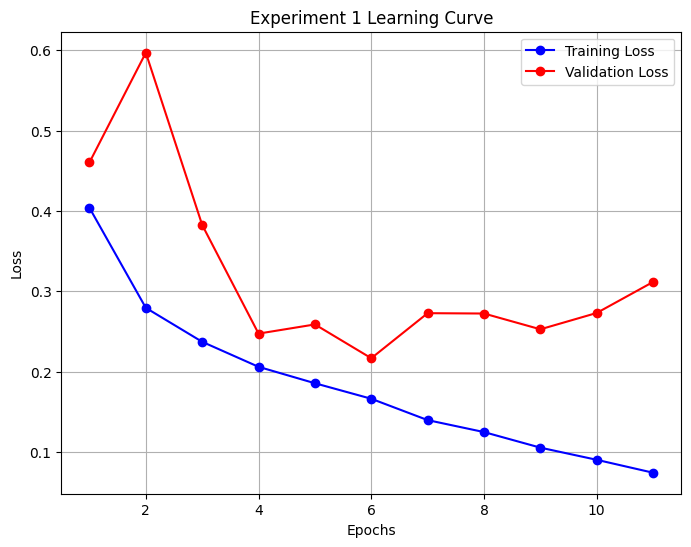

In [ ]:
import matplotlib.pyplot as plt

# training loss
train_loss = history.history['loss']

# validation loss
val_loss = history.history['val_loss']

epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(8,6))

plt.plot(epochs, train_loss, 'b-o', label='Training Loss')
plt.plot(epochs, val_loss, 'r-o', label='Validation Loss')

plt.title("Experiment 1 Learning Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)


In [ ]:
#  experiment 2

In [ ]:

model = models.Sequential()

# covn1
model.add(layers.Conv2D(64,(3,3),padding="same",activation="relu",input_shape=(28,28,1)))
model.add(layers.MaxPooling2D((2,2)))

# conv2
model.add(layers.Conv2D(128,(3,3),padding="same",activation="relu"))
model.add(layers.MaxPooling2D((2,2)))

# conv 3
model.add(layers.Conv2D(256,(3,3),padding="same",activation="relu"))

# conv 4
model.add(layers.Conv2D(256,(3,3),padding="same",activation="relu"))
model.add(layers.MaxPooling2D((2,2)))

# flatten
model.add(layers.Flatten())
# model.add(layers.Dense(256,activation="relu"))

# neuronal network

model.add(layers.Dense(1024,activation="relu"))

# layer 2

model.add(layers.Dense(1024,activation="relu"))

# bacth normalization
model.add(layers.BatchNormalization())

# output layers

model.add(layers.Dense(10,activation="softmax"))


# model summury
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 7, 7, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1024)           │     2,360,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,384,010 (16.72 MB)

 Trainable params: 4,381,962 (16.72 MB)

 Non-trainable params: 2,048 (8.00 KB)

In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate= 0.0005),loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5,restore_best_weights=True)

In [ ]:
history2 = model.fit(x_train,y_train,epochs=50,batch_size=50,
validation_data=(x_val,y_val),callbacks=[early_stopping])

Epoch 1/50
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8097 - loss: 0.5205 - val_accuracy: 0.8692 - val_loss: 0.4478
Epoch 2/50
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.8971 - loss: 0.2819 - val_accuracy: 0.9046 - val_loss: 0.2532
Epoch 3/50
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9195 - loss: 0.2230 - val_accuracy: 0.9132 - val_loss: 0.2432
Epoch 4/50
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9295 - loss: 0.1938 - val_accuracy: 0.9078 - val_loss: 0.2569
Epoch 5/50
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9422 - loss: 0.1633 - val_accuracy: 0.9000 - val_loss: 0.2698
Epoch 6/50
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9443 - loss: 0.1480 - val_accuracy: 0.8892 - val_loss: 0.3913
Epoch 7/50
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9534 - loss: 0.1260 - val_accuracy: 0.9136 - val_loss: 0.2699
Epoch 8/50
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9605 - loss: 0.

In [ ]:

val_loss, val_acc = model.evaluate(x_val, y_val)
print("Validation Accuracy:", val_acc)

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9098 - loss: 0.2510
Validation Accuracy: 0.9132000207901001


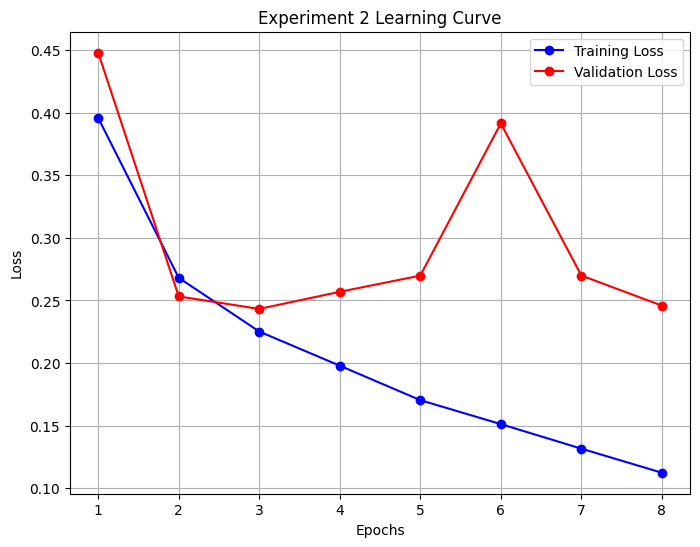

In [ ]:
import matplotlib.pyplot as plt

# training loss
train_loss = history2.history['loss']

# validation loss
val_loss = history2.history['val_loss']

epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(8,6))

plt.plot(epochs, train_loss, 'b-o', label='Training Loss')
plt.plot(epochs, val_loss, 'r-o', label='Validation Loss')

plt.title("Experiment 2 Learning Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()



In [ ]:
# experiment 3



In [ ]:

model = models.Sequential()

# covn1
model.add(layers.Conv2D(64,(3,3),padding="same",activation="relu",input_shape=(28,28,1)))
model.add(layers.MaxPooling2D((2,2)))

# conv2
model.add(layers.Conv2D(128,(3,3),padding="same",activation="relu"))
model.add(layers.MaxPooling2D((2,2)))

# conv 3
model.add(layers.Conv2D(256,(3,3),padding="same",activation="relu"))

# conv 4
model.add(layers.Conv2D(256,(3,3),padding="same",activation="relu"))
model.add(layers.MaxPooling2D((2,2)))

# flatten
model.add(layers.Flatten())
# model.add(layers.Dense(256,activation="relu"))

# neuronal network

model.add(layers.Dense(1024,activation="relu"))

# layer 2

model.add(layers.Dense(1024,activation="relu"))

# bacth normalization
model.add(layers.BatchNormalization())

# output layers

model.add(layers.Dense(10,activation="softmax"))


# model summury
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 7, 7, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 7, 7, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1024)           │     2,360,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,384,010 (16.72 MB)

 Trainable params: 4,381,962 (16.72 MB)

 Non-trainable params: 2,048 (8.00 KB)

In [ ]:
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5,restore_best_weights=True)

In [ ]:
history3 = model.fit(x_train,y_train,epochs=50,batch_size=25,
validation_data=(x_val,y_val),callbacks=[early_stopping])

Epoch 1/50
2200/2200 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.8032 - loss: 0.5469 - val_accuracy: 0.8388 - val_loss: 0.4551
Epoch 2/50
2200/2200 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - accuracy: 0.8913 - loss: 0.3016 - val_accuracy: 0.8862 - val_loss: 0.3066
Epoch 3/50
2200/2200 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.9082 - loss: 0.2551 - val_accuracy: 0.9046 - val_loss: 0.2512
Epoch 4/50
2200/2200 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.9187 - loss: 0.2213 - val_accuracy: 0.9064 - val_loss: 0.2883
Epoch 5/50
2200/2200 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9285 - loss: 0.1955 - val_accuracy: 0.8616 - val_loss: 0.7204
Epoch 6/50
2200/2200 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.9380 - loss: 0.1749 - val_accuracy: 0.9152 - val_loss: 0.2513
Epoch 7/50
2200/2200 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.9442 - loss: 0.1508 - val_accuracy: 0.9230 - val_loss: 0.2333
Epoch 8/50
2200/2200 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.9529 - loss: 0

In [ ]:
val_loss, val_acc = model.evaluate(x_val, y_val)
print("Validation Accuracy:", val_acc)

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9149 - loss: 0.2428
Validation Accuracy: 0.9229999780654907


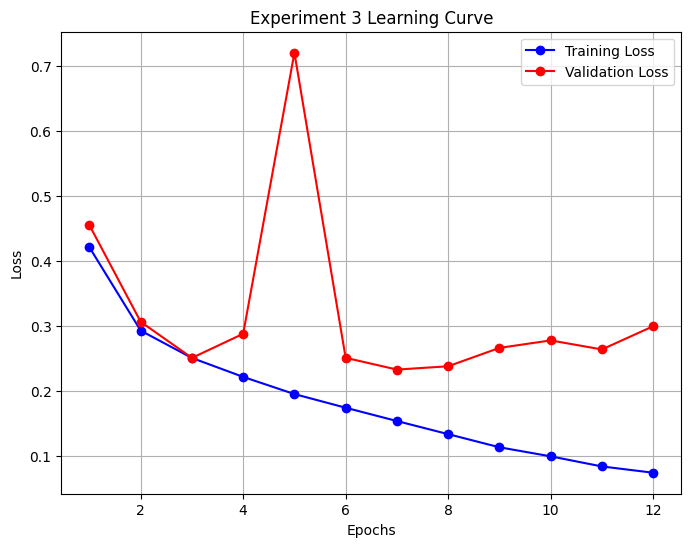

In [ ]:
import matplotlib.pyplot as plt

# training loss
train_loss = history3.history['loss']

# validation loss
val_loss = history3.history['val_loss']

epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(8,6))

plt.plot(epochs, train_loss, 'b-o', label='Training Loss')
plt.plot(epochs, val_loss, 'r-o', label='Validation Loss')

plt.title("Experiment 3 Learning Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# experimnet 4


In [ ]:
initializer = tf.keras.initializers.GlorotUniform()

In [ ]:

model = models.Sequential()

# covn1
model.add(layers.Conv2D(64,(3,3),padding="same",activation="relu", kernel_initializer=initializer,input_shape=(28,28,1)))
model.add(layers.MaxPooling2D((2,2)))

# conv2
model.add(layers.Conv2D(128,(3,3),padding="same",activation="relu", kernel_initializer=initializer,))
model.add(layers.MaxPooling2D((2,2)))

# conv 3
model.add(layers.Conv2D(256,(3,3),padding="same",activation="relu", kernel_initializer=initializer,))

# conv 4
model.add(layers.Conv2D(256,(3,3),padding="same",activation="relu", kernel_initializer=initializer,))
model.add(layers.MaxPooling2D((2,2)))

# flatten
model.add(layers.Flatten())
# model.add(layers.Dense(256,activation="relu"))

# neuronal network

model.add(layers.Dense(1024,activation="relu", kernel_initializer=initializer,))

# layer 2

model.add(layers.Dense(1024,activation="relu", kernel_initializer=initializer,))

# bacth normalization
model.add(layers.BatchNormalization())

# output layers

model.add(layers.Dense(10,activation="softmax"))


# model summury
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 7, 7, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 7, 7, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1024)           │     2,360,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,384,010 (16.72 MB)

 Trainable params: 4,381,962 (16.72 MB)

 Non-trainable params: 2,048 (8.00 KB)

In [ ]:
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5,restore_best_weights=True)

In [ ]:
history4 = model.fit(x_train,y_train,epochs=50,batch_size=50,
validation_data=(x_val,y_val),callbacks=[early_stopping])

Epoch 1/50
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9486 - loss: 0.1434 - val_accuracy: 0.9116 - val_loss: 0.2730
Epoch 2/50
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9574 - loss: 0.1153 - val_accuracy: 0.9142 - val_loss: 0.2571
Epoch 3/50
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9629 - loss: 0.0988 - val_accuracy: 0.9160 - val_loss: 0.3123
Epoch 4/50
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9703 - loss: 0.0822 - val_accuracy: 0.9238 - val_loss: 0.2610
Epoch 5/50
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9761 - loss: 0.0673 - val_accuracy: 0.9214 - val_loss: 0.2814
Epoch 6/50
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9799 - loss: 0.0565 - val_accuracy: 0.9150 - val_loss: 0.3472
Epoch 7/50
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9792 - loss: 0.0545 - val_accuracy: 0.9244 - val_loss: 0.3333


In [ ]:
val_loss, val_acc = model.evaluate(x_val, y_val)
print("Validation Accuracy:", val_acc)

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9105 - loss: 0.2682
Validation Accuracy: 0.9142000079154968


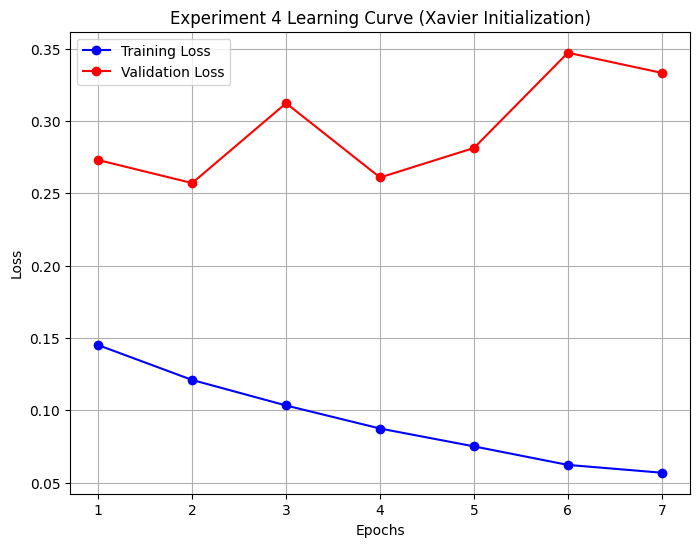

In [ ]:
import matplotlib.pyplot as plt

# training loss
train_loss = history4.history['loss']

# validation loss
val_loss = history4.history['val_loss']

epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(8,6))

plt.plot(epochs, train_loss, 'b-o', label='Training Loss')
plt.plot(epochs, val_loss, 'r-o', label='Validation Loss')

plt.title("Experiment 4 Learning Curve (Xavier Initialization)")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# experimet 5


In [15]:
initializer = tf.keras.initializers.HeNormal()

In [16]:

model = models.Sequential()

# covn1
model.add(layers.Conv2D(64,(3,3),padding="same",activation="relu", kernel_initializer=initializer,input_shape=(28,28,1)))
model.add(layers.MaxPooling2D((2,2)))

# conv2
model.add(layers.Conv2D(128,(3,3),padding="same",activation="relu", kernel_initializer=initializer,))
model.add(layers.MaxPooling2D((2,2)))

# conv 3
model.add(layers.Conv2D(256,(3,3),padding="same",activation="relu", kernel_initializer=initializer,))

# conv 4
model.add(layers.Conv2D(256,(3,3),padding="same",activation="relu", kernel_initializer=initializer,))
model.add(layers.MaxPooling2D((2,2)))

# flatten
model.add(layers.Flatten())
# model.add(layers.Dense(256,activation="relu"))

# neuronal network

model.add(layers.Dense(1024,activation="relu", kernel_initializer=initializer,))

# layer 2

model.add(layers.Dense(1024,activation="relu", kernel_initializer=initializer,))

# bacth normalization
model.add(layers.BatchNormalization())

# output layers

model.add(layers.Dense(10,activation="softmax"))


# model summury
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 7, 7, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1024)           │     2,360,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,384,010 (16.72 MB)

 Trainable params: 4,381,962 (16.72 MB)

 Non-trainable params: 2,048 (8.00 KB)

In [17]:
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [18]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5,restore_best_weights=True)

In [19]:
history5 = model.fit(x_train,y_train,epochs=50,batch_size=50,
validation_data=(x_val,y_val),callbacks=[early_stopping])

Epoch 1/50
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.8110 - loss: 0.5316 - val_accuracy: 0.8080 - val_loss: 0.5808
Epoch 2/50
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9008 - loss: 0.2751 - val_accuracy: 0.8616 - val_loss: 0.4331
Epoch 3/50
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9188 - loss: 0.2251 - val_accuracy: 0.9094 - val_loss: 0.2649
Epoch 4/50
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9326 - loss: 0.1868 - val_accuracy: 0.9192 - val_loss: 0.2291
Epoch 5/50
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9399 - loss: 0.1691 - val_accuracy: 0.8974 - val_loss: 0.3135
Epoch 6/50
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9502 - loss: 0.1418 - val_accuracy: 0.9106 - val_loss: 0.2520
Epoch 7/50
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9573 - loss: 0.1210 - val_accuracy: 0.9230 - val_loss: 0.2364
Epoch 8/50
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9656 - loss: 0.0964 -

In [20]:
val_loss, val_acc = model.evaluate(x_val, y_val)
print("Validation Accuracy:", val_acc)

157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9176 - loss: 0.2357
Validation Accuracy: 0.9192000031471252


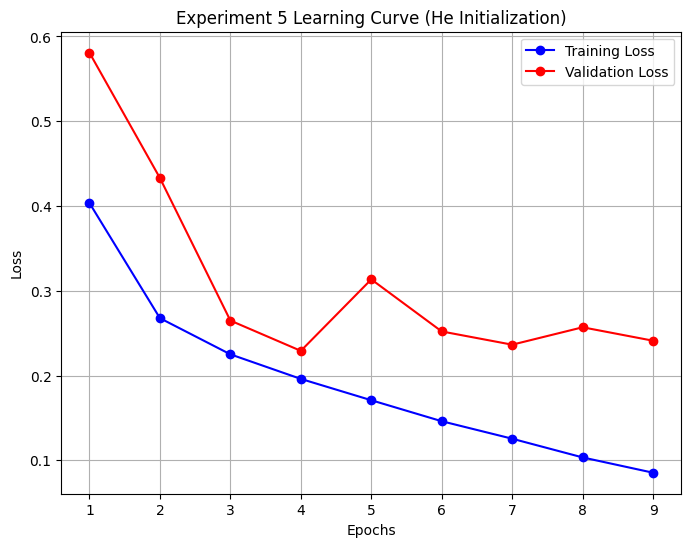

In [21]:
import matplotlib.pyplot as plt

# training loss
train_loss = history5.history['loss']

# validation loss
val_loss = history5.history['val_loss']

epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(8,6))

plt.plot(epochs, train_loss, 'b-o', label='Training Loss')
plt.plot(epochs, val_loss, 'r-o', label='Validation Loss')

plt.title("Experiment 5 Learning Curve (He Initialization)")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()

In [26]:
_ = model(x_val[:1])

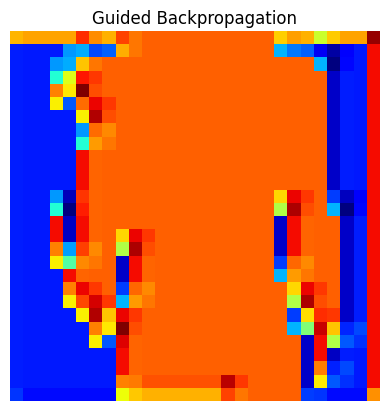

In [28]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# input image
img = x_val[0]

# expand dimension
img = np.expand_dims(img, axis=0)

# convert to tensor
img = tf.convert_to_tensor(img)

with tf.GradientTape() as tape:

    tape.watch(img)

    conv_output = model.layers[0](img)

    loss = tf.reduce_mean(conv_output[:,:,:,0])

grads = tape.gradient(loss, img)

guided_grads = grads[0]

plt.imshow(guided_grads[:,:,0], cmap="jet")
plt.title("Guided Backpropagation")
plt.axis("off")
plt.show()

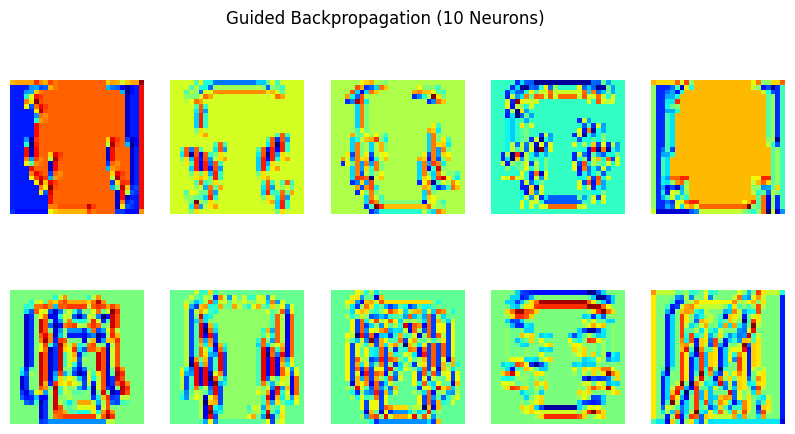

In [29]:
plt.figure(figsize=(10,5))

for i in range(10):

    img = x_val[0]
    img = np.expand_dims(img, axis=0)
    img = tf.convert_to_tensor(img)

    with tf.GradientTape() as tape:

        tape.watch(img)

        conv_output = model.layers[0](img)

        loss = tf.reduce_mean(conv_output[:,:,:,i])

    grads = tape.gradient(loss, img)

    guided_grads = grads[0]

    plt.subplot(2,5,i+1)
    plt.imshow(guided_grads[:,:,0], cmap="jet")
    plt.axis("off")

plt.suptitle("Guided Backpropagation (10 Neurons)")
plt.show()

(3, 3, 1, 64)


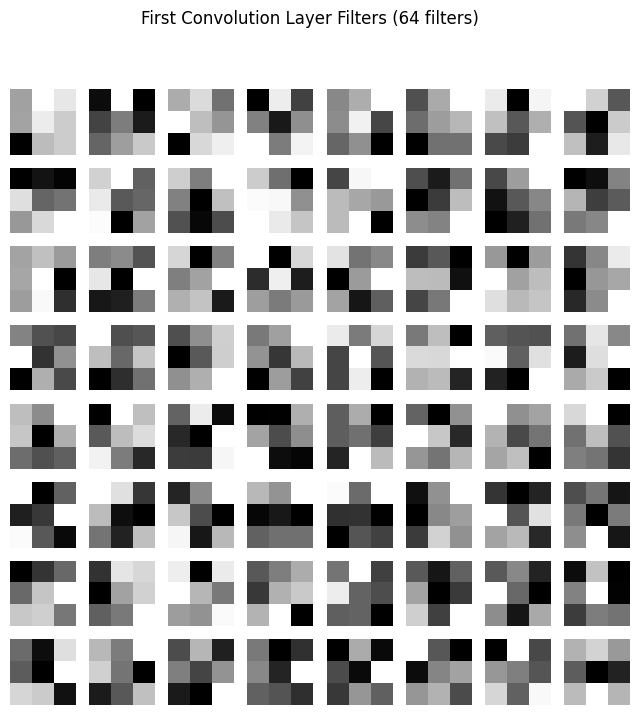

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# first conv layer filters
filters, biases = model.layers[0].get_weights()

print(filters.shape)   # (3,3,1,64)

# normalize filters
f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max - f_min)

fig, axes = plt.subplots(8,8, figsize=(8,8))

for i, ax in enumerate(axes.flat):

    f = filters[:,:,:,i]

    ax.imshow(f[:,:,0], cmap='gray')
    ax.axis('off')

plt.suptitle("First Convolution Layer Filters (64 filters)")
plt.show()

In [31]:
predictions = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


In [32]:
import numpy as np

pred_labels = np.argmax(predictions, axis=1)